# EDA - IEEE-CIS Fraud Detection

Covers:
1. Dataset shape and memory footprint
2. Class distribution (fraud rate)
3. TransactionDT - temporal structure and range
4. Identity join coverage
5. Missing value analysis
6. TransactionAmt distribution
7. Top feature correlations with isFraud

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 100

DATA_RAW = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")
DATA_PROCESSED.mkdir(exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


## 1. Dataset Shape and Memory

In [2]:
print("Loading transaction table...")
txn = pd.read_csv(DATA_RAW / "train_transaction.csv")
print("Loading identity table...")
idn = pd.read_csv(DATA_RAW / "train_identity.csv")

print(f"\ntrain_transaction: {txn.shape[0]:,} rows x {txn.shape[1]} cols  "
      f"({txn.memory_usage(deep=True).sum() / 1e6:.1f} MB)")
print(f"train_identity:    {idn.shape[0]:,} rows x {idn.shape[1]} cols  "
      f"({idn.memory_usage(deep=True).sum() / 1e6:.1f} MB)")

Loading transaction table...


Loading identity table...



train_transaction: 590,540 rows x 394 cols  (2202.7 MB)
train_identity:    144,233 rows x 41 cols  (165.3 MB)


## 2. Class Distribution

Not fraud : 569,877  (96.50%)
Fraud     :  20,663  (3.50%)

Class imbalance ratio: 27.6:1


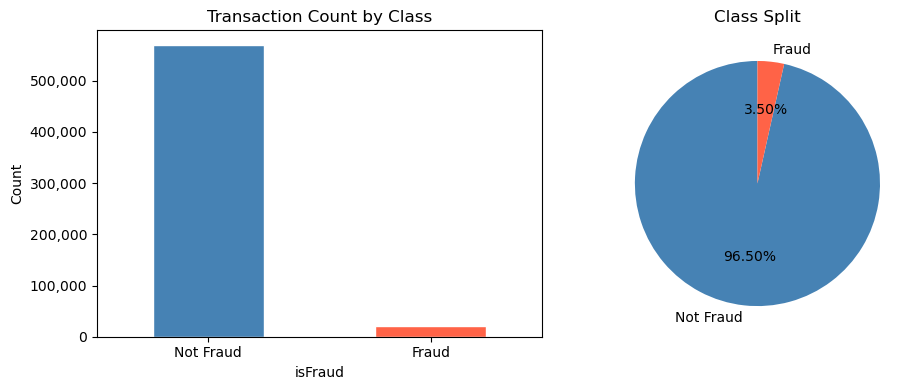

In [3]:
fraud_counts = txn["isFraud"].value_counts()
fraud_rate = txn["isFraud"].mean() * 100

print(f"Not fraud : {fraud_counts[0]:>7,}  ({100 - fraud_rate:.2f}%)")
print(f"Fraud     : {fraud_counts[1]:>7,}  ({fraud_rate:.2f}%)")
print(f"\nClass imbalance ratio: {fraud_counts[0] / fraud_counts[1]:.1f}:1")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
fraud_counts.plot(kind="bar", ax=ax[0], color=["steelblue", "tomato"], edgecolor="white")
ax[0].set_xticklabels(["Not Fraud", "Fraud"], rotation=0)
ax[0].set_title("Transaction Count by Class")
ax[0].set_ylabel("Count")
ax[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

ax[1].pie(
    fraud_counts,
    labels=["Not Fraud", "Fraud"],
    colors=["steelblue", "tomato"],
    autopct="%1.2f%%",
    startangle=90,
)
ax[1].set_title("Class Split")
plt.tight_layout()
plt.show()

## 3. TransactionDT - Temporal Structure

TransactionDT range : 86,400 - 15,811,131 seconds
Span                : 182.0 days  (~6.1 months)
Median              : 7,306,528 sec  (84.6 days)


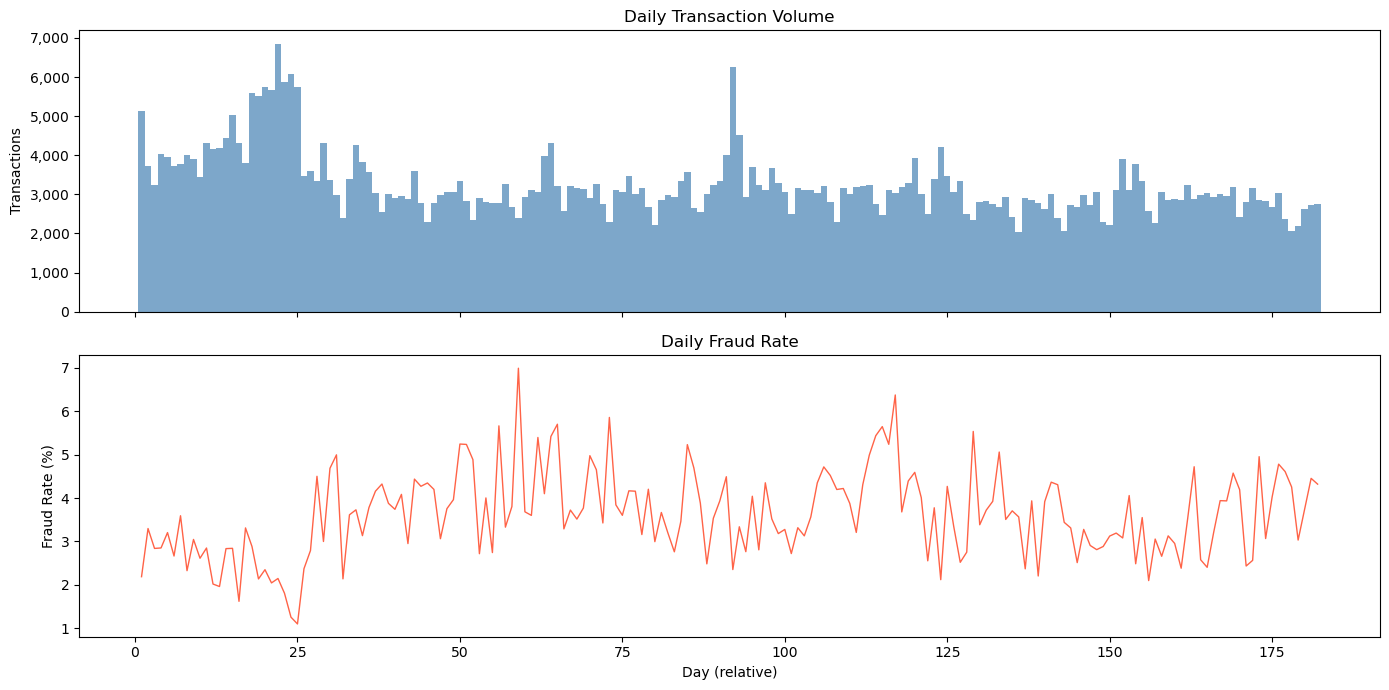


Proposed split boundaries (TransactionDT):
  Train : 0          -> 10,438,003  (413,378 rows)
  Val   : 10,438,003 -> 13,151,880  (88,581 rows)
  Test  : 13,151,880 -> 15,811,131  (88,581 rows)


In [4]:
# TransactionDT is seconds elapsed since a reference point (not a real timestamp)
dt = txn["TransactionDT"]
dt_days = dt / 86400  # convert to days

print(f"TransactionDT range : {dt.min():,} - {dt.max():,} seconds")
print(f"Span                : {(dt.max() - dt.min()) / 86400:.1f} days  (~{(dt.max() - dt.min()) / 86400 / 30:.1f} months)")
print(f"Median              : {dt.median():,.0f} sec  ({dt.median() / 86400:.1f} days)")

# Transactions per day bucket
txn["dt_day"] = (txn["TransactionDT"] // 86400).astype(int)
daily = txn.groupby("dt_day").agg(total=("isFraud", "count"), fraud=("isFraud", "sum")).reset_index()
daily["fraud_rate"] = daily["fraud"] / daily["total"]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].bar(daily["dt_day"], daily["total"], color="steelblue", alpha=0.7, width=1)
axes[0].set_ylabel("Transactions")
axes[0].set_title("Daily Transaction Volume")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

axes[1].plot(daily["dt_day"], daily["fraud_rate"] * 100, color="tomato", linewidth=1)
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].set_xlabel("Day (relative)")
axes[1].set_title("Daily Fraud Rate")

plt.tight_layout()
plt.show()

# Train/val/test split boundaries (70/15/15 chronological)
n = len(txn)
sorted_dt = txn["TransactionDT"].sort_values()
train_end = sorted_dt.iloc[int(n * 0.70)]
val_end = sorted_dt.iloc[int(n * 0.85)]
print(f"\nProposed split boundaries (TransactionDT):")
print(f"  Train : 0          -> {train_end:,}  ({int(n*0.70):,} rows)")
print(f"  Val   : {train_end:,} -> {val_end:,}  ({int(n*0.15):,} rows)")
print(f"  Test  : {val_end:,} -> {dt.max():,}  ({n - int(n*0.85):,} rows)")

## 4. Identity Join Coverage

In [5]:
n_txn = len(txn)
n_with_identity = txn["TransactionID"].isin(idn["TransactionID"]).sum()
n_without_identity = n_txn - n_with_identity

print(f"Total transactions         : {n_txn:,}")
print(f"Have identity row          : {n_with_identity:,}  ({n_with_identity/n_txn*100:.1f}%)")
print(f"No identity row            : {n_without_identity:,}  ({n_without_identity/n_txn*100:.1f}%)")

# Fraud rate split by identity coverage
has_id = txn["TransactionID"].isin(idn["TransactionID"])
print(f"\nFraud rate WITH identity   : {txn[has_id]['isFraud'].mean()*100:.2f}%")
print(f"Fraud rate WITHOUT identity: {txn[~has_id]['isFraud'].mean()*100:.2f}%")
print("\nNote: identity features will be NaN for ~{:.0f}% of transactions after join.".format(
    n_without_identity / n_txn * 100
))

Total transactions         : 590,540
Have identity row          : 144,233  (24.4%)
No identity row            : 446,307  (75.6%)



Fraud rate WITH identity   : 7.85%


Fraud rate WITHOUT identity: 2.09%

Note: identity features will be NaN for ~76% of transactions after join.


## 5. Missing Value Analysis

Transaction table: 374 features with missing values
  >80% missing: 55 features
  >50% missing: 174 features
  >20% missing: 212 features
  <5%  missing: 92 features


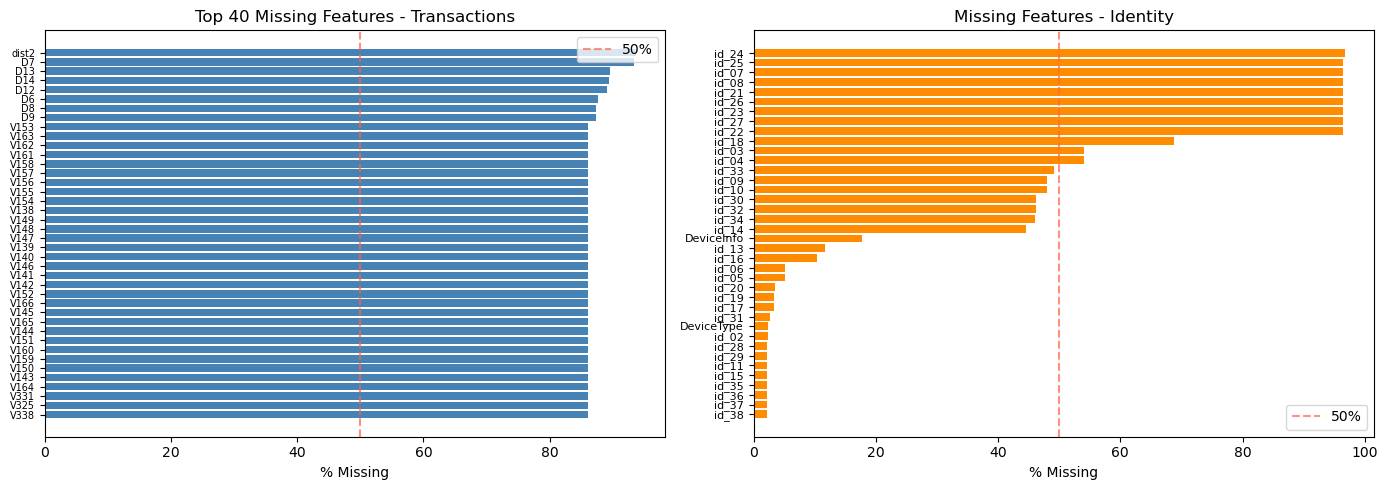

In [6]:
# Missing rates per feature - transaction table
txn_missing = (txn.isnull().sum() / len(txn) * 100).sort_values(ascending=False)
txn_missing = txn_missing[txn_missing > 0]

print(f"Transaction table: {len(txn_missing)} features with missing values")
print(f"  >80% missing: {(txn_missing > 80).sum()} features")
print(f"  >50% missing: {(txn_missing > 50).sum()} features")
print(f"  >20% missing: {(txn_missing > 20).sum()} features")
print(f"  <5%  missing: {(txn_missing < 5).sum()} features")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transaction table missing rates (top 40)
top40_txn = txn_missing.head(40)
axes[0].barh(range(len(top40_txn)), top40_txn.values, color="steelblue")
axes[0].set_yticks(range(len(top40_txn)))
axes[0].set_yticklabels(top40_txn.index, fontsize=7)
axes[0].invert_yaxis()
axes[0].set_xlabel("% Missing")
axes[0].set_title("Top 40 Missing Features - Transactions")
axes[0].axvline(50, color="tomato", linestyle="--", alpha=0.7, label="50%")
axes[0].legend()

# Identity table missing rates
idn_missing = (idn.isnull().sum() / len(idn) * 100).sort_values(ascending=False)
idn_missing = idn_missing[idn_missing > 0]
axes[1].barh(range(len(idn_missing)), idn_missing.values, color="darkorange")
axes[1].set_yticks(range(len(idn_missing)))
axes[1].set_yticklabels(idn_missing.index, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_xlabel("% Missing")
axes[1].set_title("Missing Features - Identity")
axes[1].axvline(50, color="tomato", linestyle="--", alpha=0.7, label="50%")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. TransactionAmt Distribution

TransactionAmt summary:
  Min    : $      0.25
  p25    : $     43.32


  Median : $     68.77
  Mean   : $    135.03
  p95    : $    445.00
  p99    : $   1104.00
  Max    : $  31937.39


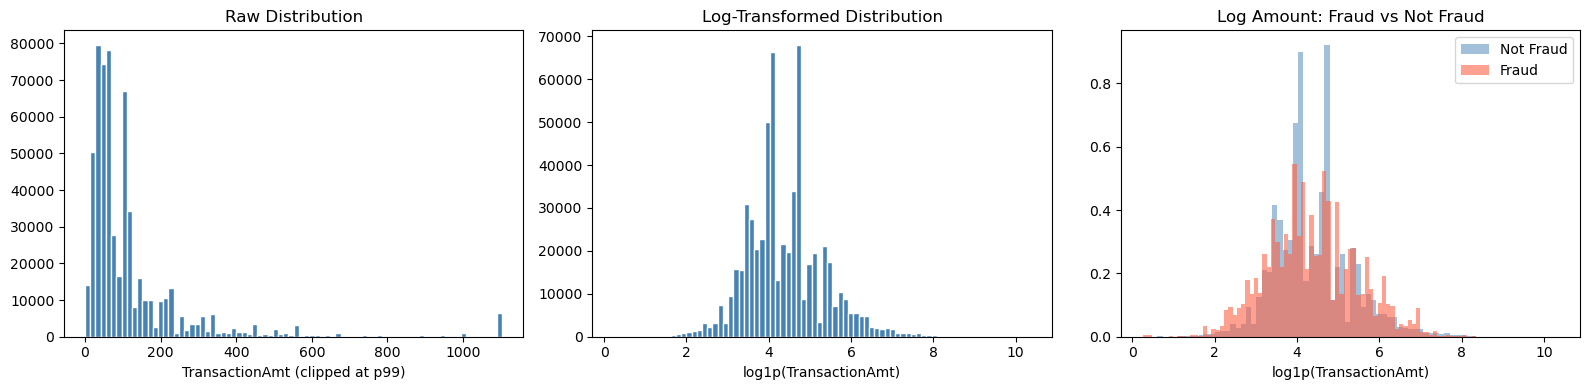

In [7]:
amt = txn["TransactionAmt"]

print("TransactionAmt summary:")
print(f"  Min    : ${amt.min():>10.2f}")
print(f"  p25    : ${amt.quantile(0.25):>10.2f}")
print(f"  Median : ${amt.median():>10.2f}")
print(f"  Mean   : ${amt.mean():>10.2f}")
print(f"  p95    : ${amt.quantile(0.95):>10.2f}")
print(f"  p99    : ${amt.quantile(0.99):>10.2f}")
print(f"  Max    : ${amt.max():>10.2f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw distribution (clipped at p99 for readability)
clip_val = amt.quantile(0.99)
axes[0].hist(amt.clip(upper=clip_val), bins=80, color="steelblue", edgecolor="white")
axes[0].set_xlabel("TransactionAmt (clipped at p99)")
axes[0].set_title("Raw Distribution")

# Log distribution
axes[1].hist(np.log1p(amt), bins=80, color="steelblue", edgecolor="white")
axes[1].set_xlabel("log1p(TransactionAmt)")
axes[1].set_title("Log-Transformed Distribution")

# Fraud vs not-fraud KDE on log scale
log_amt = np.log1p(txn["TransactionAmt"])
axes[2].hist(log_amt[txn["isFraud"] == 0], bins=80, alpha=0.5, color="steelblue",
             label="Not Fraud", density=True)
axes[2].hist(log_amt[txn["isFraud"] == 1], bins=80, alpha=0.6, color="tomato",
             label="Fraud", density=True)
axes[2].set_xlabel("log1p(TransactionAmt)")
axes[2].set_title("Log Amount: Fraud vs Not Fraud")
axes[2].legend()

plt.tight_layout()
plt.show()

## 7. Top Feature Correlations with isFraud

Top 20 features by |correlation| with isFraud:
V257   0.3831
V246   0.3669
V244   0.3641
V242   0.3606
V201   0.3280
V200   0.3188
V189   0.3082
V188   0.3036
V258   0.2972
V45    0.2818
V158   0.2781
V156   0.2760
V149   0.2733
V228   0.2689
V44    0.2604
V86    0.2518
V87    0.2517
V170   0.2498
V147   0.2429
V52    0.2395


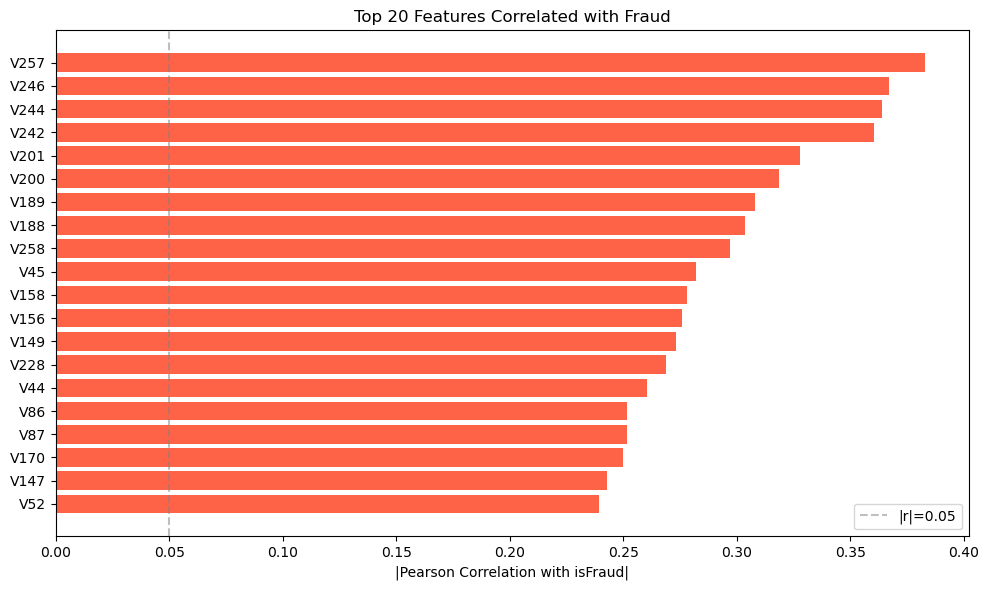

In [8]:
# Pearson correlation of numeric features with isFraud
# Only numeric cols; drop TransactionID and dt_day (artifacts)
numeric_cols = txn.select_dtypes(include=[np.number]).columns.tolist()
drop_cols = ["TransactionID", "dt_day", "isFraud"]
numeric_cols = [c for c in numeric_cols if c not in drop_cols]

corr_with_target = (
    txn[numeric_cols + ["isFraud"]]
    .corr()["isFraud"]
    .drop("isFraud")
    .abs()
    .sort_values(ascending=False)
)

top20 = corr_with_target.head(20)
bottom10 = corr_with_target.tail(10)

print("Top 20 features by |correlation| with isFraud:")
print(top20.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["tomato" if v > 0.05 else "steelblue" for v in top20.values]
ax.barh(range(len(top20)), top20.values, color=colors)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index)
ax.invert_yaxis()
ax.set_xlabel("|Pearson Correlation with isFraud|")
ax.set_title("Top 20 Features Correlated with Fraud")
ax.axvline(0.05, color="gray", linestyle="--", alpha=0.5, label="|r|=0.05")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Card Feature Analysis


card4 value counts:
card4
visa                384767
mastercard          189217
american express      8328
discover              6651

card4 fraud rate:
card4
discover            7.73%
visa                3.48%
mastercard          3.43%
american express    2.87%

card6 value counts:
card6
debit              439938
credit             148986
debit or credit        30
charge card            15

card6 fraud rate:
card6
credit             6.68%
debit              2.43%
charge card        0.00%
debit or credit    0.00%


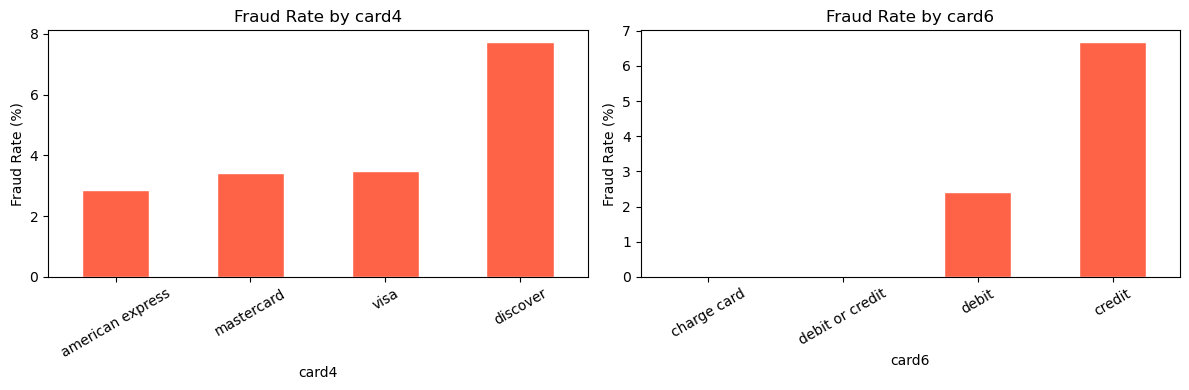

In [9]:
# card4 = card network (visa/mastercard), card6 = card type (credit/debit)
for col in ["card4", "card6"]:
    if col in txn.columns:
        vc = txn[col].value_counts()
        fraud_rate_by_cat = txn.groupby(col)["isFraud"].mean().sort_values(ascending=False)
        print(f"\n{col} value counts:")
        print(vc.to_string())
        print(f"\n{col} fraud rate:")
        print(fraud_rate_by_cat.map(lambda x: f"{x*100:.2f}%").to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["card4", "card6"]):
    if col in txn.columns:
        fraud_by_cat = txn.groupby(col)["isFraud"].mean() * 100
        fraud_by_cat.sort_values().plot(kind="bar", ax=ax, color="tomato", edgecolor="white")
        ax.set_title(f"Fraud Rate by {col}")
        ax.set_ylabel("Fraud Rate (%)")
        ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 9. EDA Summary and Feature Engineering Decisions

Key findings to carry into `02_feature_engineering.ipynb`:

- Record findings here after running the notebook


In [10]:
# Summary stats to carry forward
summary = {
    "n_transactions": len(txn),
    "fraud_rate_pct": round(txn["isFraud"].mean() * 100, 3),
    "identity_coverage_pct": round(n_with_identity / n_txn * 100, 1),
    "dt_span_days": round((txn["TransactionDT"].max() - txn["TransactionDT"].min()) / 86400, 1),
    "features_gt50pct_missing": int((txn_missing > 50).sum()),
    "top5_corr_features": top20.head(5).index.tolist(),
}

for k, v in summary.items():
    print(f"{k:40s}: {v}")

n_transactions                          : 590540
fraud_rate_pct                          : 3.499
identity_coverage_pct                   : 24.4
dt_span_days                            : 182.0
features_gt50pct_missing                : 174
top5_corr_features                      : ['V257', 'V246', 'V244', 'V242', 'V201']
